# MatPlotLib #

In [223]:
# Import Libraries

# Data Management
import pandas as pd
import numpy as np

# Plots
import matplotlib.pyplot as plt

# Handle Files
import sys
import os

# Import Local Functions
sys.path.append(os.path.abspath("../source"))
from config import get_tickers
from data_downloader import get_market_data

In [224]:
tickers = get_tickers("7.1")

tickers

['AMZN', 'F', 'WMT']

In [225]:
# DataFrame to store everything
returns_df = pd.DataFrame()

for ticker in tickers:
    df_stock = get_market_data(
        ticker=ticker, 
        start_date='2019-01-01', 
        end_date='2025-01-01', 
        returns=True
    )
    
    returns = df_stock['returns'].rename(ticker)
    
    returns_df = pd.concat([returns_df, returns], axis=1)

In [226]:
# Dates
returns_df.index = pd.to_datetime(returns_df.index)
returns_df

,AMZN,F,WMT
2019-01-03,-0.025566,-0.015307,-0.005156
2019-01-04,0.048851,0.037836,0.006227
2019-01-07,0.033777,0.025658,0.011704
2019-01-08,0.016476,0.009604,0.006957
2019-01-09,0.001713,0.040965,-0.003262
...,...,...,...
2024-12-24,0.017573,0.012048,0.025462
2024-12-26,-0.008770,0.004978,0.001186
2024-12-27,-0.014641,-0.003980,-0.012253
2024-12-30,-0.011010,-0.015068,-0.011963


### Line Plots ###

<Axes: >

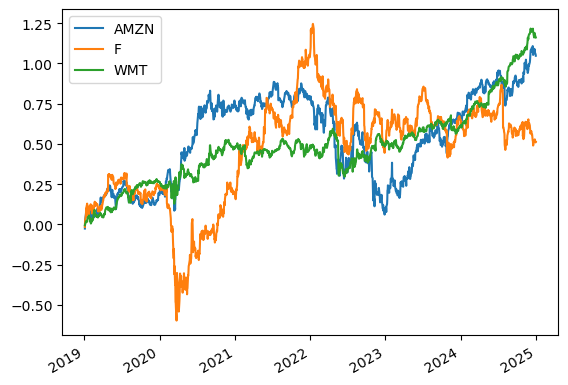

In [227]:
# The most common way to visualize data is using the .plot() method with pandas
returns_df.cumsum().plot()

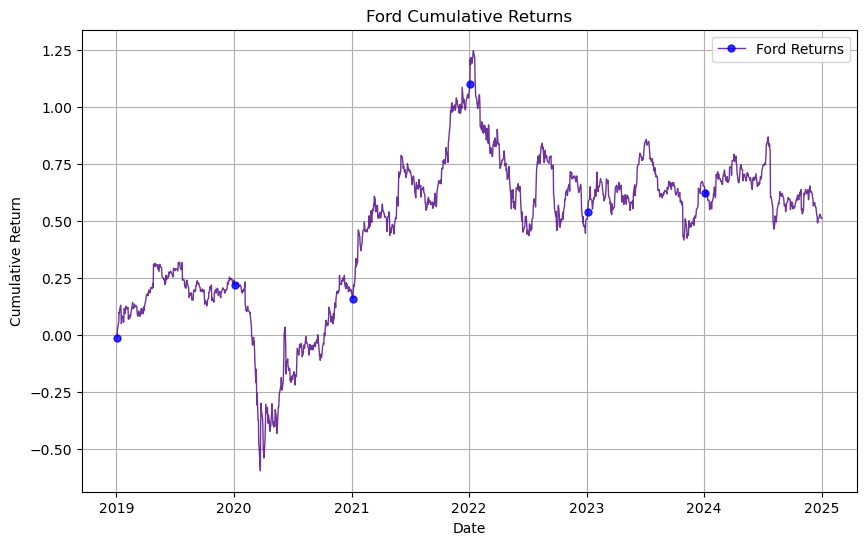

In [228]:
# First let's create a plot
plt.figure(figsize=(10,6))                  # Define the Size of the Plot
plt.plot(
    returns_df.index,                       # X-Axis (Dates)
    returns_df['F'].cumsum(),               # The Variable you want to plot
    label='Ford Returns',                   # Label for the Data
    color="#4B0082",                        # You can use Hex Colors or the names of the colors (but its limited)
    linestyle="-",                          # You can use "--" to have a dotted line
    linewidth=1,                            # Width of the line
    marker="o",                             # Add Markers
    markersize=5,                           # Markers' Size
    markerfacecolor='blue',                 # Markers' Face Color
    markeredgecolor='b',                    # Markers' Edge Color
    markevery=252,                          # Markers' Frequency
    alpha=0.8,                              # Line transparency
)                                  

plt.title("Ford Cumulative Returns")        # Add the Title
plt.xlabel("Date")                          # X Label
plt.ylabel("Cumulative Return")             # Y Label
plt.legend()                                # Show Legends

plt.grid()                                  # Adding Grid
plt.show()                                  # Show the Plot

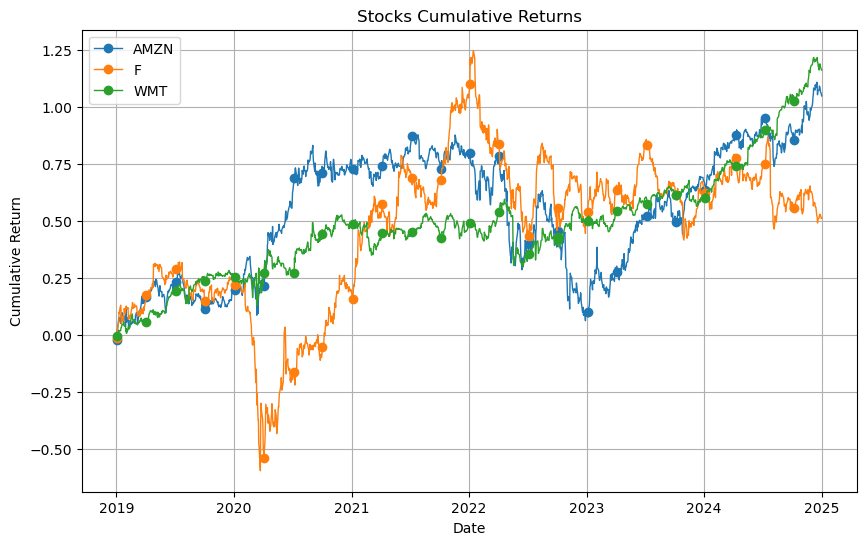

In [229]:
# We can use the whole data frame to plot
plt.figure(figsize=(10,6))                      # Define the Size of the Plot
plt.plot(
    returns_df.index,                           # X-Axis (Dates)
    returns_df.cumsum(),                        # The DataFrame
    label=returns_df.columns,                   # Use the columns as the labels
    linestyle="-",                              # You can use "--" to have a dotted line
    linewidth=1,                                # Width of the line
    marker="o",                                 # Add Markers
    markersize=6,                               # Markers' Size
    markevery=63,                               # Markers' Frequency
    alpha=1,                                    # Line transparency
)                                  

plt.title("Stocks Cumulative Returns")          # Add the Title
plt.xlabel("Date")                              # X Label
plt.ylabel("Cumulative Return")                 # Y Label
plt.legend()                                    # Show Legends

plt.grid()                                      # Adding Grid
plt.show()                                      # Show the Plot

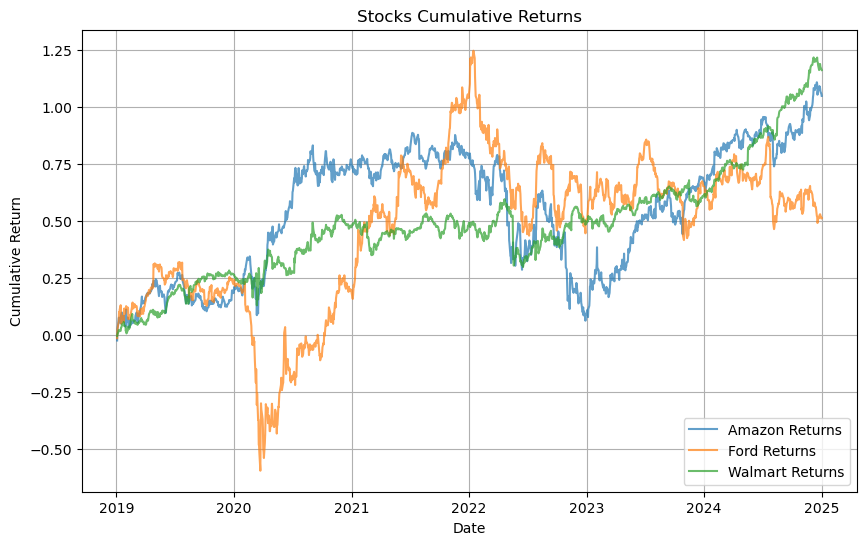

In [230]:
# We can also create plot by plot
plt.figure(figsize=(10,6))
plt.plot(returns_df.index, returns_df['AMZN'].cumsum(), label='Amazon Returns', alpha = 0.7)
plt.plot(returns_df.index, returns_df['F'].cumsum(), label='Ford Returns', alpha = 0.7)
plt.plot(returns_df.index, returns_df['WMT'].cumsum(), label='Walmart Returns', alpha = 0.7)

plt.title("Stocks Cumulative Returns")          # Add the Title
plt.xlabel("Date")                              # X Label
plt.ylabel("Cumulative Return")                 # Y Label
plt.legend(loc='lower right')                   # Use loc to set the position of the labels

plt.grid()                                      # Adding Grid
plt.show()   

### Bar Plots ###

In [231]:
# Create Annual Returns
annual_returns = returns_df.groupby(returns_df.index.year).mean()
annual_returns = annual_returns * 252

annual_returns

,AMZN,F,WMT
2019,0.183528,0.228338,0.262622
2020,0.564527,-0.039380,0.208804
2021,0.023490,0.864917,0.019516
2022,-0.688212,-0.550022,-0.004668
2023,0.597410,0.148048,0.122137
2024,0.367365,-0.140432,0.553841


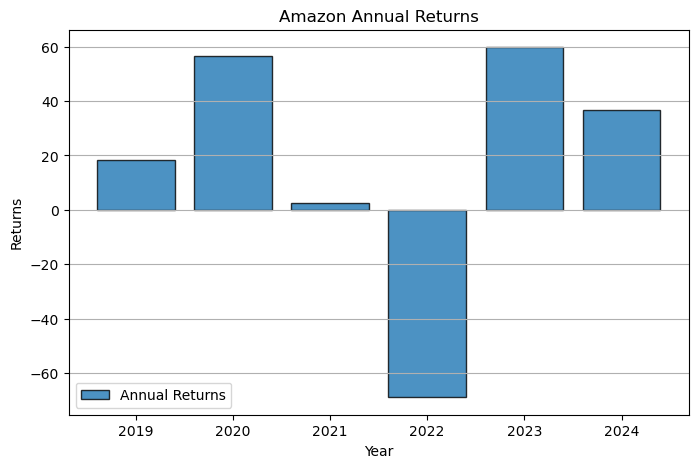

In [232]:
# Create the Bar Plot
categories = annual_returns.index
values = annual_returns['AMZN']

plt.figure(figsize=(8,5))
plt.bar(
    categories,                     # Categories
    values * 100,                   # Values
    color="#1f77b4",                # Color
    edgecolor="black",              # Edges
    linewidth=1,                    # Edge Width
    alpha=0.8,                      # Transparency
    label = "Annual Returns",        # Label
)

plt.title("Amazon Annual Returns")      # Add the Title
plt.xlabel("Year")                      # X Label
plt.ylabel("Returns")                   # Y Label

plt.grid(axis='y')
plt.legend(loc='best', fontsize=10)
plt.show()

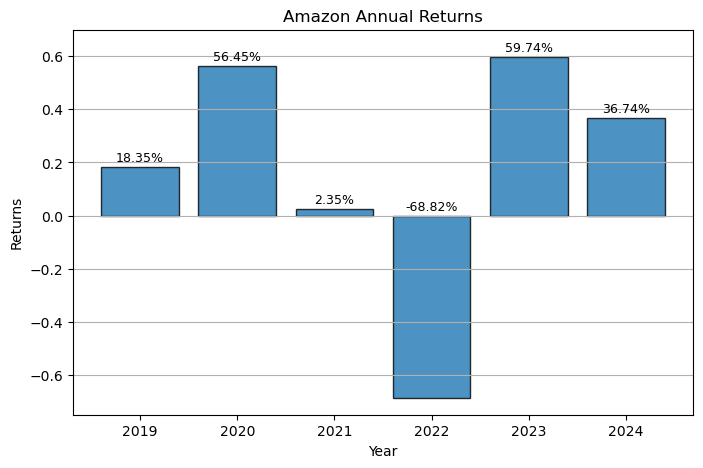

In [233]:
# Labels for Bars
plt.figure(figsize=(8,5))
bars = plt.bar(
    categories,                                     # Categories
    values,                                         # Values
    color="#1f77b4",                                # Color
    edgecolor="black",                              # Edges
    linewidth=1,                                    # Edge Width
    alpha=0.8,                                      # Transparency
)

# Add Labels
for bar in bars:
    yval = bar.get_height()                         # Height of the Bar
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 0.01 if yval > 0 else 0.01,          # Positioning Label over the Bar
        f"{yval:.2%}",                              # Percentage Format
        ha="center",                                # Centering Text
        va="bottom",                                # Vertical Position
        fontsize=9,                                 # Font Size
    )
    
plt.title("Amazon Annual Returns")      # Add the Title
plt.xlabel("Year")                      # X Label
plt.ylabel("Returns")                   # Y Label

plt.ylim(-0.75, 0.7)                     # Y Limits

plt.grid(axis='y')
plt.show()

In [234]:
# Suppose an Equal Weighted Portfolio
ewp = annual_returns * 1/3
ewp 

,AMZN,F,WMT
2019,0.061176,0.076113,0.087541
2020,0.188176,-0.013127,0.069601
2021,0.007830,0.288306,0.006505
2022,-0.229404,-0.183341,-0.001556
2023,0.199137,0.049349,0.040712
2024,0.122455,-0.046811,0.184614


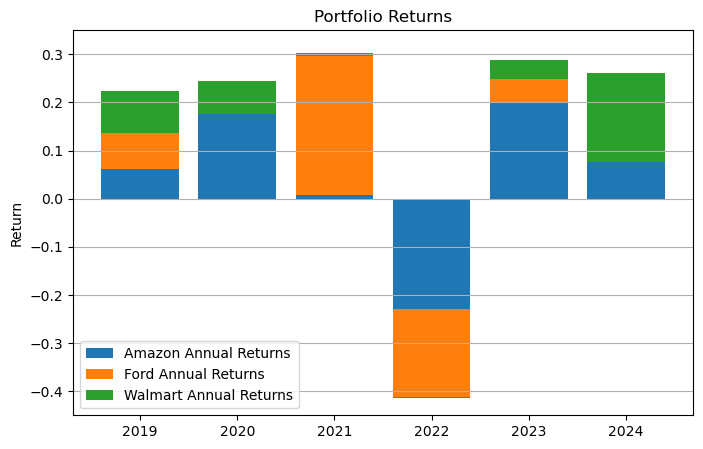

In [235]:
# Example with your DataFrame columns
x = np.arange(len(ewp.index))   # positions on the X-axis

plt.figure(figsize=(8,5))

# Amazon first (base)
plt.bar(x, ewp['AMZN'], label="Amazon Annual Returns")

# Ford on top of Amazon
plt.bar(x, ewp['F'], bottom=ewp['AMZN'], label="Ford Annual Returns")

# Walmart on top of Amazon + Ford
plt.bar(x, ewp['WMT'], bottom=ewp['AMZN'] + ewp['F'], label="Walmart Annual Returns")

plt.xticks(x, ewp.index)
plt.title("Portfolio Returns")
plt.ylabel("Return")
plt.legend()

plt.ylim(-0.45, 0.35)

plt.grid(axis='y')
plt.show()

In [236]:
# Create Annual Returns
annual_vols = returns_df.groupby(returns_df.index.year).std()
annual_vols = annual_vols * np.sqrt(252)

annual_vols

,AMZN,F,WMT
2019,0.228305,0.271897,0.143398
2020,0.384150,0.556979,0.311569
2021,0.241562,0.413321,0.168123
2022,0.501294,0.494081,0.270851
2023,0.329107,0.355315,0.158288
2024,0.280993,0.370804,0.175089


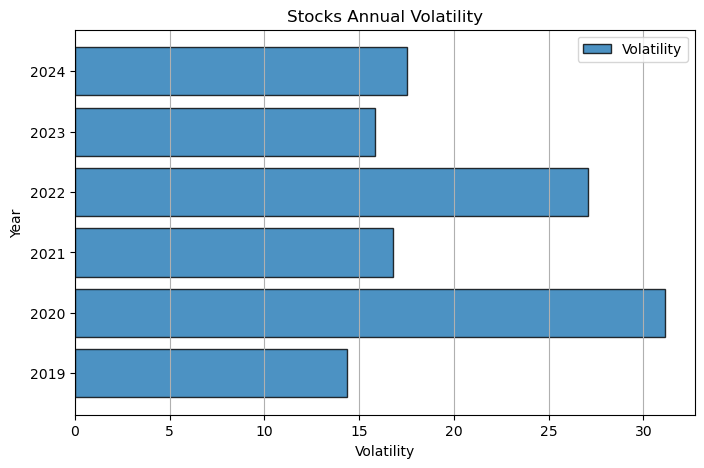

In [237]:
# Horizontal Bars
plt.figure(figsize=(8,5))
plt.barh(
    annual_vols.index,                      # Categories
    annual_vols['WMT'] * 100,               # Values
    color="#1f77b4",                        # Color
    edgecolor="black",                      # Edges
    linewidth=1,                            # Edge Width
    alpha=0.8,                              # Transparency
    label = "Volatility",                   # Label
)

plt.title("Stocks Annual Volatility")       # Add the Title
plt.ylabel("Year")                          # X Label
plt.xlabel("Volatility")                    # Y Label

plt.grid(axis='x')
plt.legend(loc='best', fontsize=10)
plt.show()

# Scatter Plots #

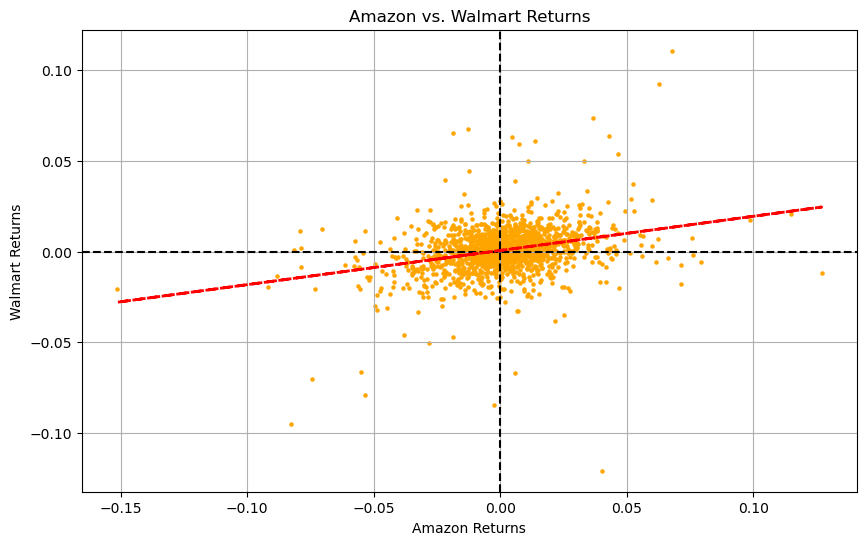

In [238]:
# Scatter Plot
plt.figure(figsize=(10,6))
plt.scatter(
    x=returns_df['AMZN'],       # X Axis Variable
    y=returns_df['WMT'],        # Y Axis Variable
    color="orange",             # Dots Color
    s=5,                        # Dots Size
    marker='o'                  # Dots Shape
)

# Lines in the zeros
plt.axhline(y=0, color='black', linestyle='--')
plt.axvline(x=0, color='black', linestyle='--')

# Tendency Line
slope, intercept = np.polyfit(returns_df['AMZN'], returns_df['WMT'], 1)     # First X then Y
plt.plot(
    returns_df['AMZN'], 
    slope*returns_df['AMZN'] + intercept, 
    color='red', 
    label='Trend line',
    linestyle='--', 
    linewidth=2, 
)

plt.title("Amazon vs. Walmart Returns")       
plt.ylabel("Walmart Returns")                          
plt.xlabel("Amazon Returns")                    

plt.grid()
plt.show()

In [239]:
#Create Year Variable
roll = 63

amazon_std = returns_df['AMZN'].rolling(window=roll).std()
amazon_std.dropna(inplace=True)

walmart_std = returns_df['WMT'].rolling(window=roll).std()
walmart_std.dropna(inplace=True)

correlations = returns_df['AMZN'].rolling(window=roll).corr(returns_df['WMT'])
correlations.dropna(inplace=True)

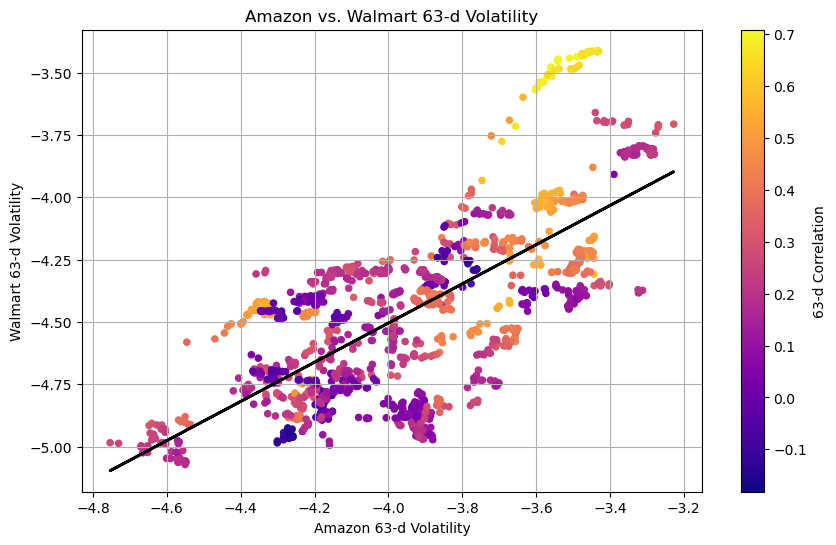

In [240]:
# Scatter Plot using colors
plt.figure(figsize=(10,6))
scatter = plt.scatter(
    x=np.log(amazon_std),                         # X Axis Variable (daily returns)
    y=np.log(walmart_std),                        # Y Axis Variable (daily returns)
    c=correlations,                       # Color by Year
    cmap='plasma',                        # Color map
    s=20,                                 # Dots Size
    marker='o'                            # Dots Shape
)

# Tendency Line
slope, intercept = np.polyfit(np.log(amazon_std), np.log(walmart_std), 1)     # First X then Y
plt.plot(
    np.log(amazon_std), 
    slope*np.log(amazon_std) + intercept, 
    color='black', 
    label='Trend line',
    linestyle='-', 
    linewidth=2, 
)


plt.title(f"Amazon vs. Walmart {roll}-d Volatility")       
plt.ylabel(f"Walmart {roll}-d Volatility")                          
plt.xlabel(f"Amazon {roll}-d Volatility")                    

plt.colorbar(scatter, label=f'{roll}-d Correlation')  # Adds the color legend
plt.grid(True)
plt.show()

### Multiple Plots ###

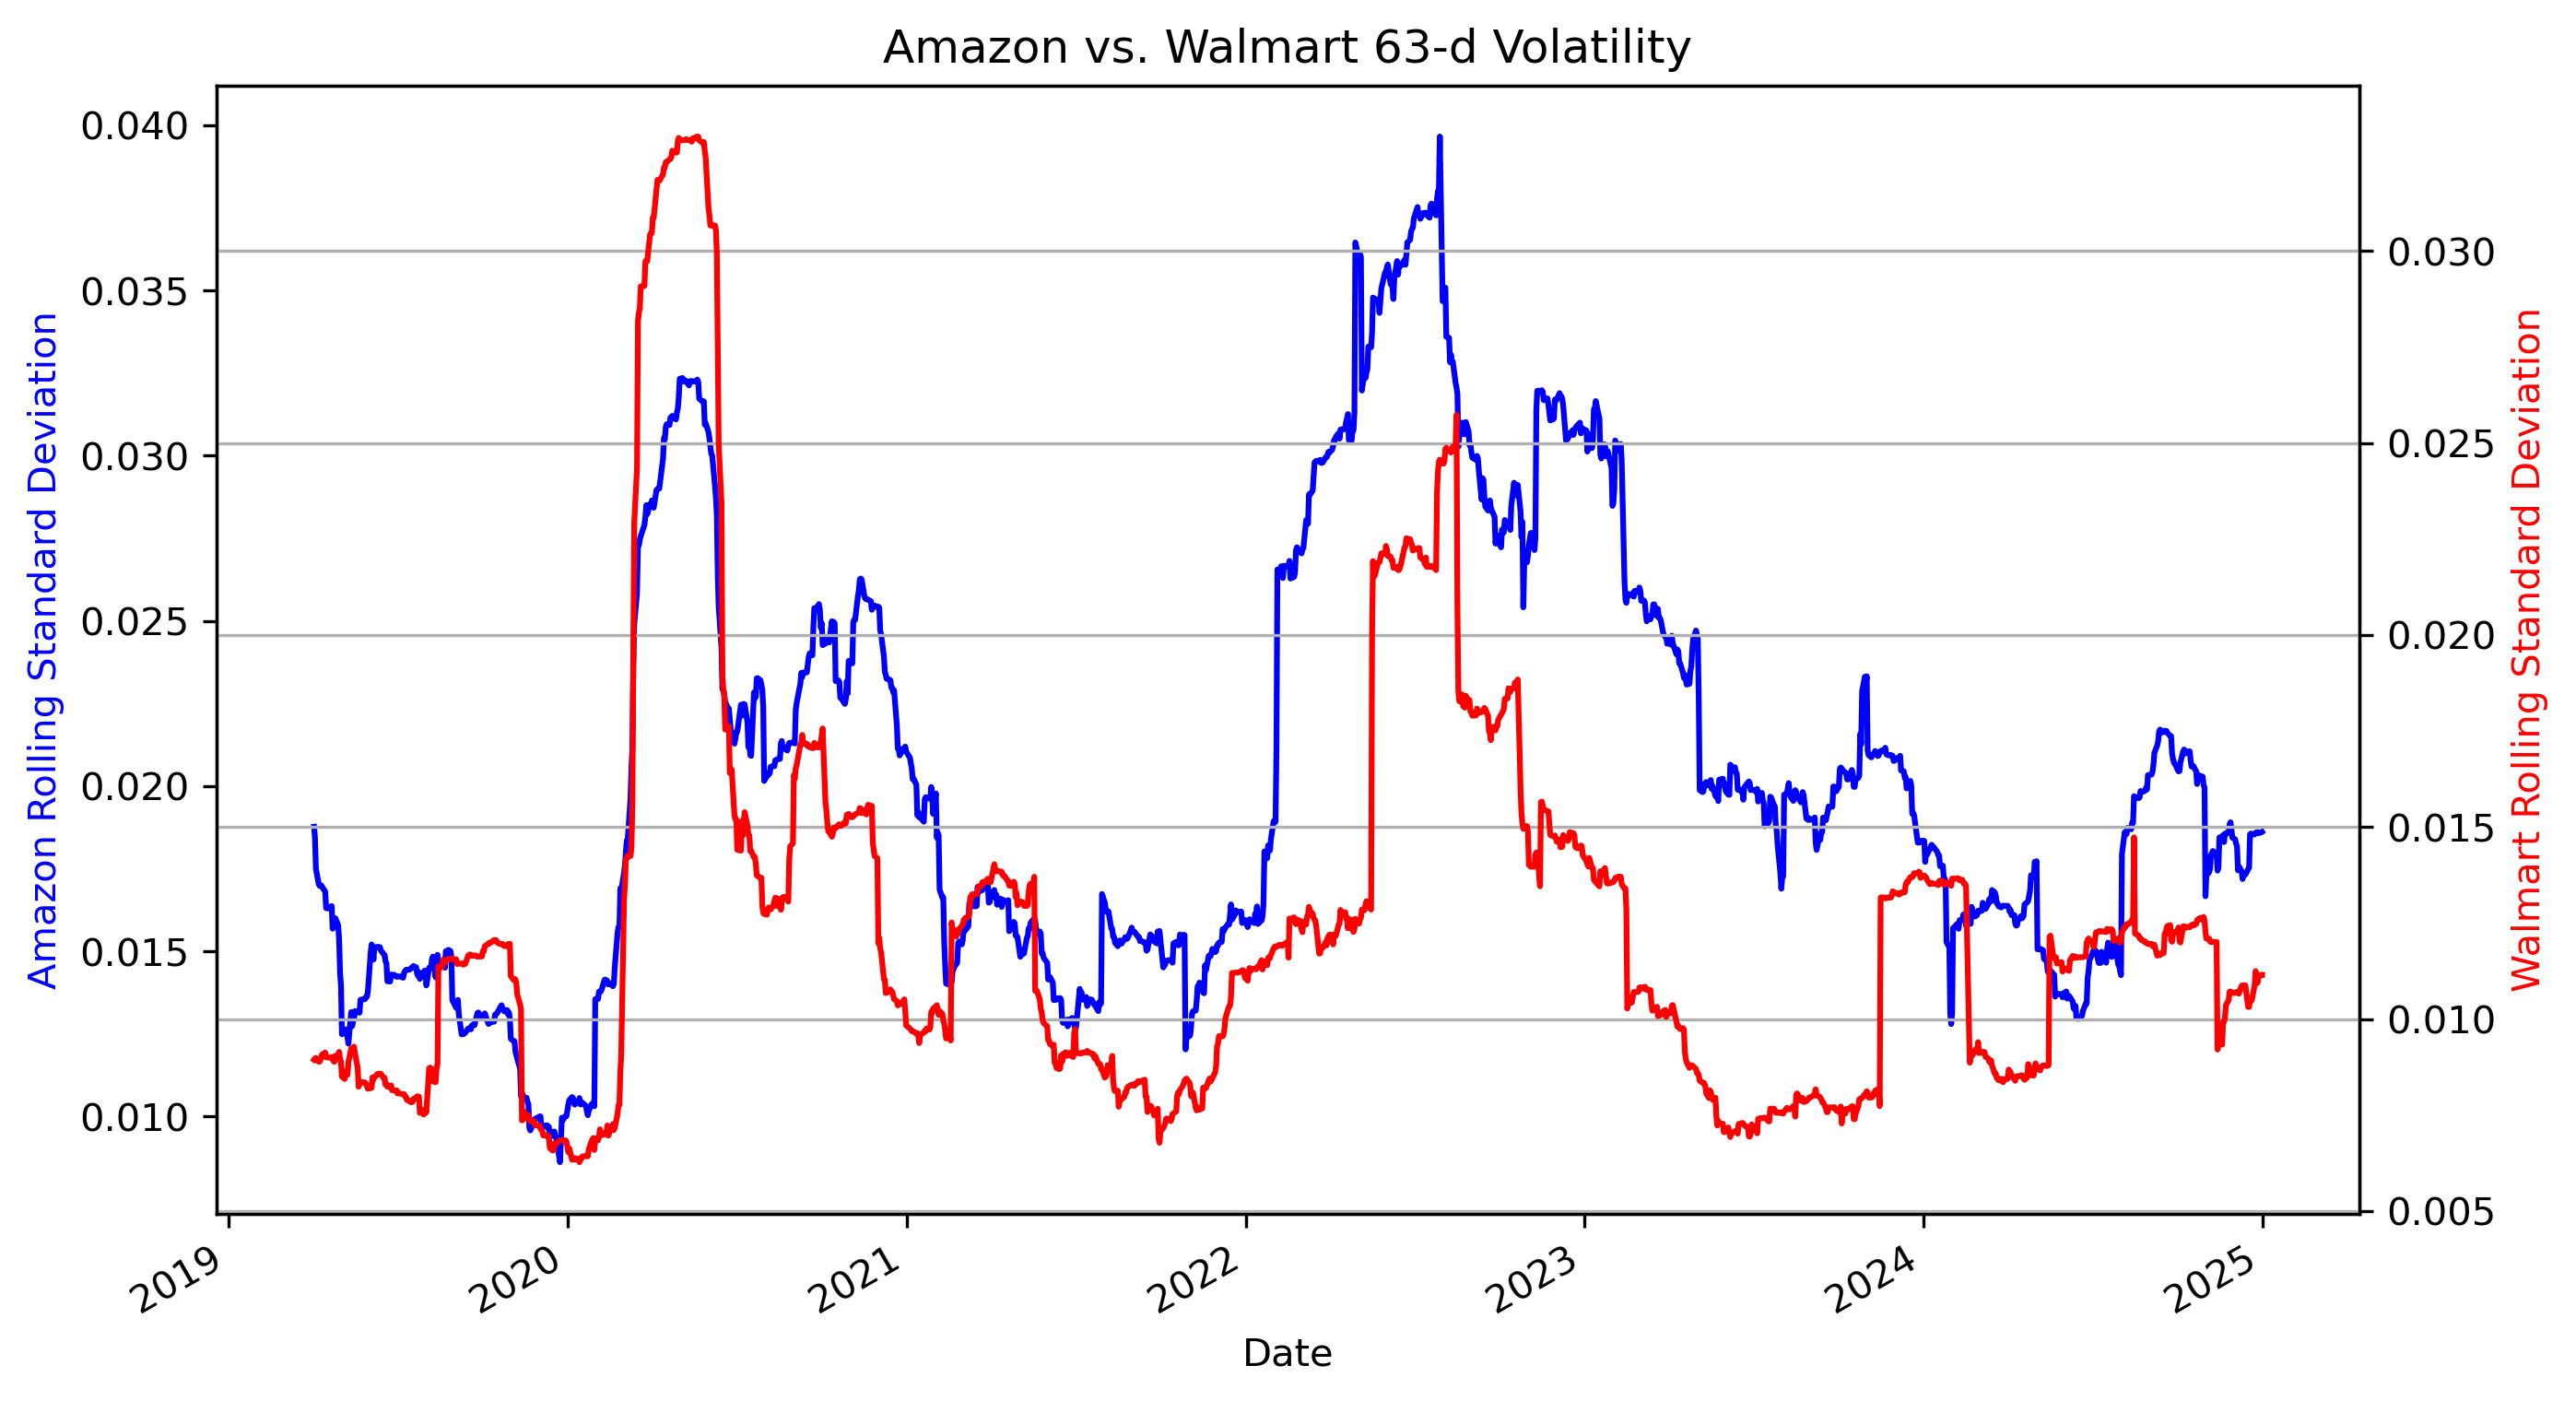

In [241]:
# Create Figure and Axis
fig, ax1 = plt.subplots(dpi = 300, figsize=(10,6))

# First Axis
amazon_std.plot(color = 'blue', ax = ax1)
ax1.set_xlabel('Date')
ax1.set_ylabel(
    'Amazon Rolling Standard Deviation', 
    color='blue'
    )

# Second Axis (Twin of the First One)
ax2 = ax1.twinx()
walmart_std.plot(color = 'red', ax = ax2)
ax2.set_ylabel(
    'Walmart Rolling Standard Deviation', 
    color='red'
    )

plt.title(f"Amazon vs. Walmart {roll}-d Volatility")

plt.grid()
plt.show()

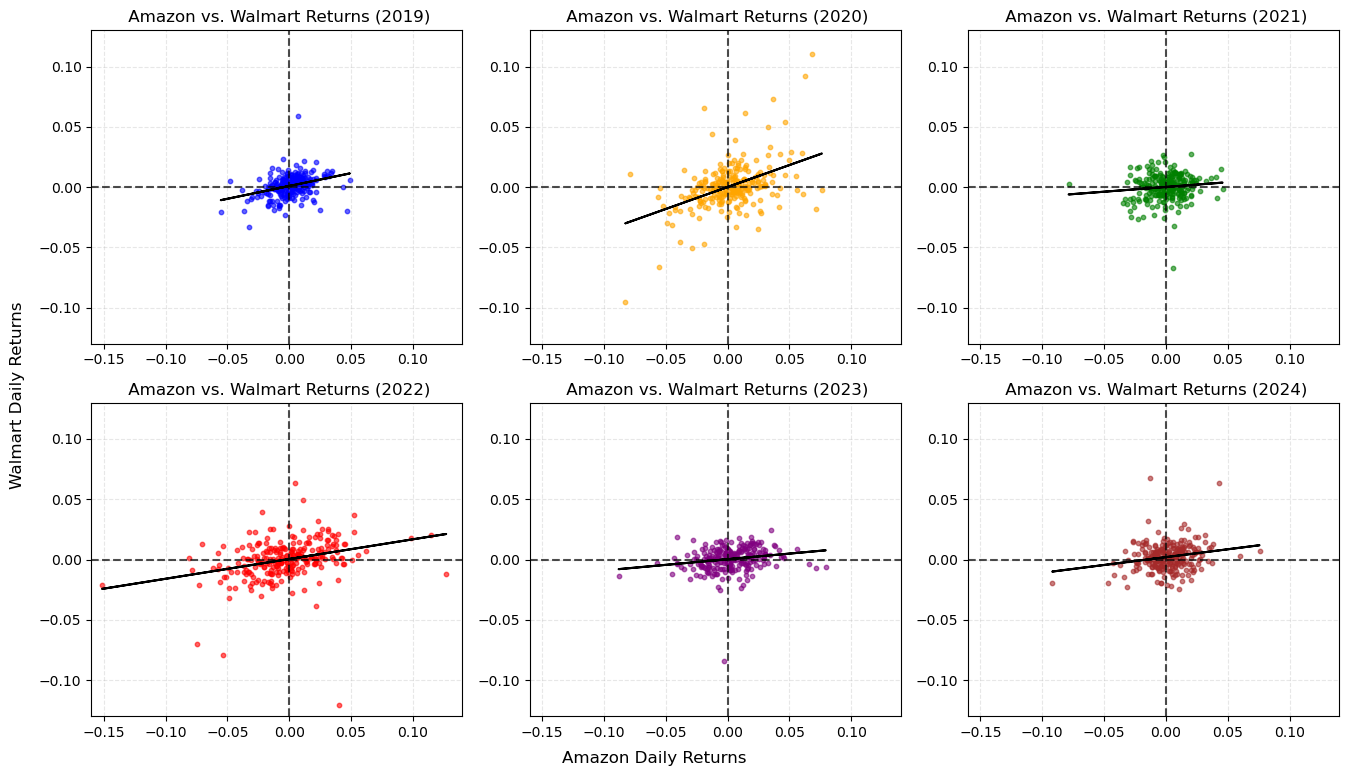

In [246]:
# Subplots
fig, ax = plt.subplots(2, 3, figsize=(14,8))
years = ['2019','2020','2021','2022','2023','2024']
colors = ['blue','orange','green','red','purple','brown']

for i, year in enumerate(years):
    row = i // 3
    col = i % 3
    ax[row,col].scatter(
        x=returns_df['AMZN'].loc[year],
        y=returns_df['WMT'].loc[year],
        s=10,
        alpha=0.6,
        color=colors[i]
    )
    
    x = returns_df['AMZN'].loc[year]
    y = returns_df['WMT'].loc[year]
    
    # Add trend line
    slope, intercept = np.polyfit(x, y, 1)
    ax[row,col].plot(x, slope*x + intercept, color='black', linewidth=1.5)
    
    ax[row,col].set_title(f' Amazon vs. Walmart Returns ({year})')
    ax[row,col].grid(True, linestyle='--', alpha=0.3)
    ax[row,col].axhline(0, color='black', linestyle='--', alpha=0.7)
    ax[row,col].axvline(0, color='black', linestyle='--', alpha=0.7)
    ax[row,col].set_ylim(-0.13, 0.13)
    ax[row,col].set_xlim(-0.16, 0.14)
    
# Global axis labels
fig.text(0.5, 0.04, 'Amazon Daily Returns', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'Walmart Daily Returns', va='center', rotation='vertical', fontsize=12)

plt.tight_layout(rect=[0.05,0.05,1,1])  # leave space for global labels
plt.show()